In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob

In [2]:
scl_binary = ["DIFFINST", "CWCM", "MQI_CHECK", "ORIENT", "SUMM"]
scl_three = ["APLPROB", "DIRINST", "ETCA", "EXPL", "LANGIMP", "LCP", "LINK", "LLC", "MAJERR", "MGEN", "MLANG", "MMETH", "MQI3", "OERR", "ORICH", "OWWS", "REMED", "SMQR", "STEXPL", "USEPROD", "WCDISS"]
scl_four = ["MATCON", "MMSM", "OERR4", "ORICH4", "OSPMMR4", "OWWS4", "SMALDIS", "STUCON"]
scl_five = ["LESSEFFIC", "MQI5", "TASKDEVMAT", "TSTUDEA"] 
all_variables = scl_binary + scl_three + scl_four + scl_five
len(all_variables)

38

In [3]:
folder_path = "../datasets"

files = os.listdir(folder_path)
MQI_files = [f for f in files if f.startswith("MQI") and f.endswith(".csv")]
print(len(MQI_files))

50


In [4]:
selected_files = [
    f for f in glob.glob("../datasets/MQI_*_dataset.csv")
    if f.split("MQI_", 1)[1].split("_dataset.csv")[0] in all_variables
]
len(selected_files)

38

# Count courses per teacher per year

In [5]:
# 1) Build ratings_df from selected_files

frames = []

for path in selected_files:
    base = os.path.basename(path)
    
    # Extract variable name from filename
    variable = base.split("MQI_", 1)[1].split("_dataset.csv")[0].upper()
    
    df = pd.read_csv(
        path,
        dtype={
            "NCTETID": "string",
            "OBSID": "string"
        }
    )
    
    # Keep only necessary columns
    tmp = df[["NCTETID", "OBSID", "SCHOOLYEAR_SP"]].copy()
    tmp["variable"] = variable
    
    frames.append(tmp)

ratings_df = pd.concat(frames, ignore_index=True)

# Normalize types
ratings_df["NCTETID"] = ratings_df["NCTETID"].astype(str)
ratings_df["OBSID"] = ratings_df["OBSID"].astype(str)
ratings_df["SCHOOLYEAR_SP"] = ratings_df["SCHOOLYEAR_SP"].astype(int)
ratings_df["variable"] = ratings_df["variable"].astype(str).str.upper()

In [7]:
# 2) Automatically compute "variables available per year" from selected_files
vars_per_year = (
    ratings_df.groupby("SCHOOLYEAR_SP")["variable"]
    .unique()
    .apply(lambda arr: set(arr))
    .to_dict()
)

n_vars_year = {year: len(vars_set) for year, vars_set in vars_per_year.items()}

print("Variables per year (from selected_files):")
for y in sorted(n_vars_year):
    print(y, n_vars_year[y], sorted(vars_per_year[y]))

Variables per year (from selected_files):
2011 26 ['APLPROB', 'CWCM', 'DIFFINST', 'DIRINST', 'ETCA', 'EXPL', 'LANGIMP', 'LCP', 'LINK', 'MAJERR', 'MGEN', 'MLANG', 'MMETH', 'MQI3', 'MQI5', 'MQI_CHECK', 'OERR', 'ORICH', 'ORIENT', 'OWWS', 'REMED', 'SMQR', 'STEXPL', 'SUMM', 'USEPROD', 'WCDISS']
2012 31 ['APLPROB', 'CWCM', 'DIFFINST', 'DIRINST', 'ETCA', 'EXPL', 'LANGIMP', 'LCP', 'LINK', 'LLC', 'MAJERR', 'MGEN', 'MLANG', 'MMETH', 'MQI3', 'MQI5', 'MQI_CHECK', 'OERR', 'OERR4', 'ORICH', 'ORICH4', 'ORIENT', 'OSPMMR4', 'OWWS', 'OWWS4', 'REMED', 'SMQR', 'STEXPL', 'SUMM', 'USEPROD', 'WCDISS']
2013 26 ['CWCM', 'ETCA', 'EXPL', 'LANGIMP', 'LCP', 'LESSEFFIC', 'LINK', 'MAJERR', 'MATCON', 'MGEN', 'MLANG', 'MMETH', 'MMSM', 'MQI5', 'OERR4', 'ORICH4', 'OSPMMR4', 'OWWS4', 'REMED', 'SMALDIS', 'SMQR', 'STEXPL', 'STUCON', 'TASKDEVMAT', 'TSTUDEA', 'WCDISS']


In [ ]:
# 3) Coverage per course (teacher x OBSID x year)
course_coverage = (
    ratings_df.groupby(["NCTETID", "OBSID", "SCHOOLYEAR_SP"])["variable"]
    .nunique()
    .reset_index(name="n_variables_present")
)

course_coverage["n_variables_possible"] = course_coverage["SCHOOLYEAR_SP"].map(n_vars_year)

course_coverage["coverage"] = (
    course_coverage["n_variables_present"] /
    course_coverage["n_variables_possible"]
)

course_coverage

Every lesson has been evaluated on each variable available this year (coverage = 1).

In [ ]:
# 4) Teacher ranking by number of courses
# Total courses per teacher
total_courses = (
    ratings_df.groupby("NCTETID")["OBSID"]
    .nunique()
    .rename("total_courses")
)

# Courses per teacher per year
courses_per_year = (
    ratings_df.groupby(["NCTETID", "SCHOOLYEAR_SP"])["OBSID"]
    .nunique()
    .unstack(fill_value=0)   # years become columns
)

# Combine both
teacher_summary_courses = (
    pd.concat([total_courses, courses_per_year], axis=1)
    .sort_values("total_courses", ascending=False)
)

teacher_summary_courses

# Choose a list of teachers

## At least 3 lessons rated per year

In [10]:
teachers_at_least_3_per_year = teacher_summary_courses[
    (teacher_summary_courses[2011] >= 3) &
    (teacher_summary_courses[2012] >= 3) &
    (teacher_summary_courses[2013] >= 3)
]

teachers_list = teachers_at_least_3_per_year.index.tolist()
len(teachers_list)

48

## Calculate the min-max scaled mean per teacher

In [11]:
# Your teacher list
teacher_ids = set(teachers_list)

results = []
scale_info = {}  # store min/max per variable
for path in selected_files:
    base = os.path.basename(path)
    variable = base.split("MQI_", 1)[1].split("_dataset.csv")[0].upper()

    df = pd.read_csv(
        path,
        dtype={"NCTETID": "string", "OBSID": "string"}
    )


    # Identify rater columns automatically
    rater_cols = [c for c in df.columns if "Rater " in c]
    if not rater_cols:
        print("No rater columns found in", path)
        continue

    # Keep only selected teachers
    df = df[df["NCTETID"].isin(teacher_ids)]
    
    # Step 1: mean across raters (row-level)
    df["mean_human_rating"] = df[rater_cols].mean(axis=1, skipna=True)

    # Step 2: handle CHAPNUM if present
    if "CHAPNUM" in df.columns:
        # mean per section first (OBSID + CHAPNUM)
        section_means = (
            df.groupby(["NCTETID", "OBSID", "CHAPNUM"])["mean_human_rating"]
            .mean()
            .reset_index()
        )

        # then mean across sections -> course-level
        course_means = (
            section_means.groupby(["NCTETID", "OBSID"])["mean_human_rating"]
            .mean()
            .reset_index(name="course_mean_rating")
        )
    else:
        # already course-level
        course_means = (
            df.groupby(["NCTETID", "OBSID"])["mean_human_rating"]
            .mean()
            .reset_index(name="course_mean_rating")
        )

    course_means["variable"] = variable
    results.append(course_means)

final_df = pd.concat(results, ignore_index=True)

In [12]:
def get_min_max(variable):
    if variable in scl_binary:
        return (0, 1)
    elif variable in scl_three:
        return (1, 3)
    elif variable in scl_four:
        return (1, 4)
    elif variable in scl_five:
        return (1, 5)
    else:
        return (None, None)
    
def normalize(row):
    var = row["variable"]
    min, max = get_min_max(var)
    return (row["course_mean_rating"] - min) / (max - min)

In [ ]:
final_df["normalized_score"] = final_df.apply(normalize, axis=1)
final_df

In [ ]:
wide_df = (
    final_df
    .pivot_table(
        index=["NCTETID", "OBSID"],
        columns="variable",
        values="normalized_score"
    )
    .reset_index()
)

# Correction for variables where higher is worse (reverse the scale)
reversed_var = ["LANGIMP", "LCP", "MAJERR", "OERR", "OERR4"]
for var in reversed_var:
    if var in wide_df.columns:
        wide_df[var] = 1 - wide_df[var]
wide_df

In [ ]:
course_scores = (
    final_df
    .groupby(["NCTETID","OBSID"])["normalized_score"]
    .agg(
        course_composite_score="mean",
        sd="std",
        n="count"
    )
    .reset_index()
)

course_scores["se"] = (
    course_scores["sd"] / np.sqrt(course_scores["n"])
)

course_scores

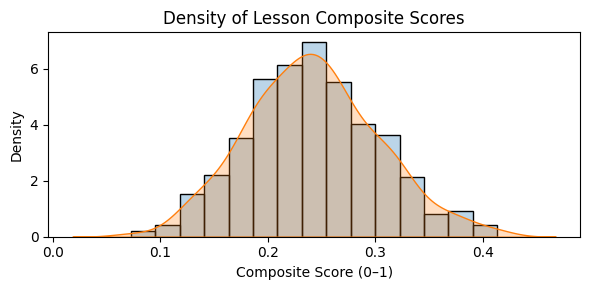

In [16]:
fig, ax = plt.subplots(figsize=(6, 3))

sns.histplot(
    data=course_scores,
    x="course_composite_score",
    stat="density",
    bins=15,
    alpha=0.3
)

sns.kdeplot(
    data=course_scores,
    x="course_composite_score",
    fill=True,
    ax=ax
)

ax.set_xlabel("Composite Score (0–1)")
ax.set_ylabel("Density")
ax.set_title("Density of Lesson Composite Scores")

plt.tight_layout()

## Display the teacher mean score

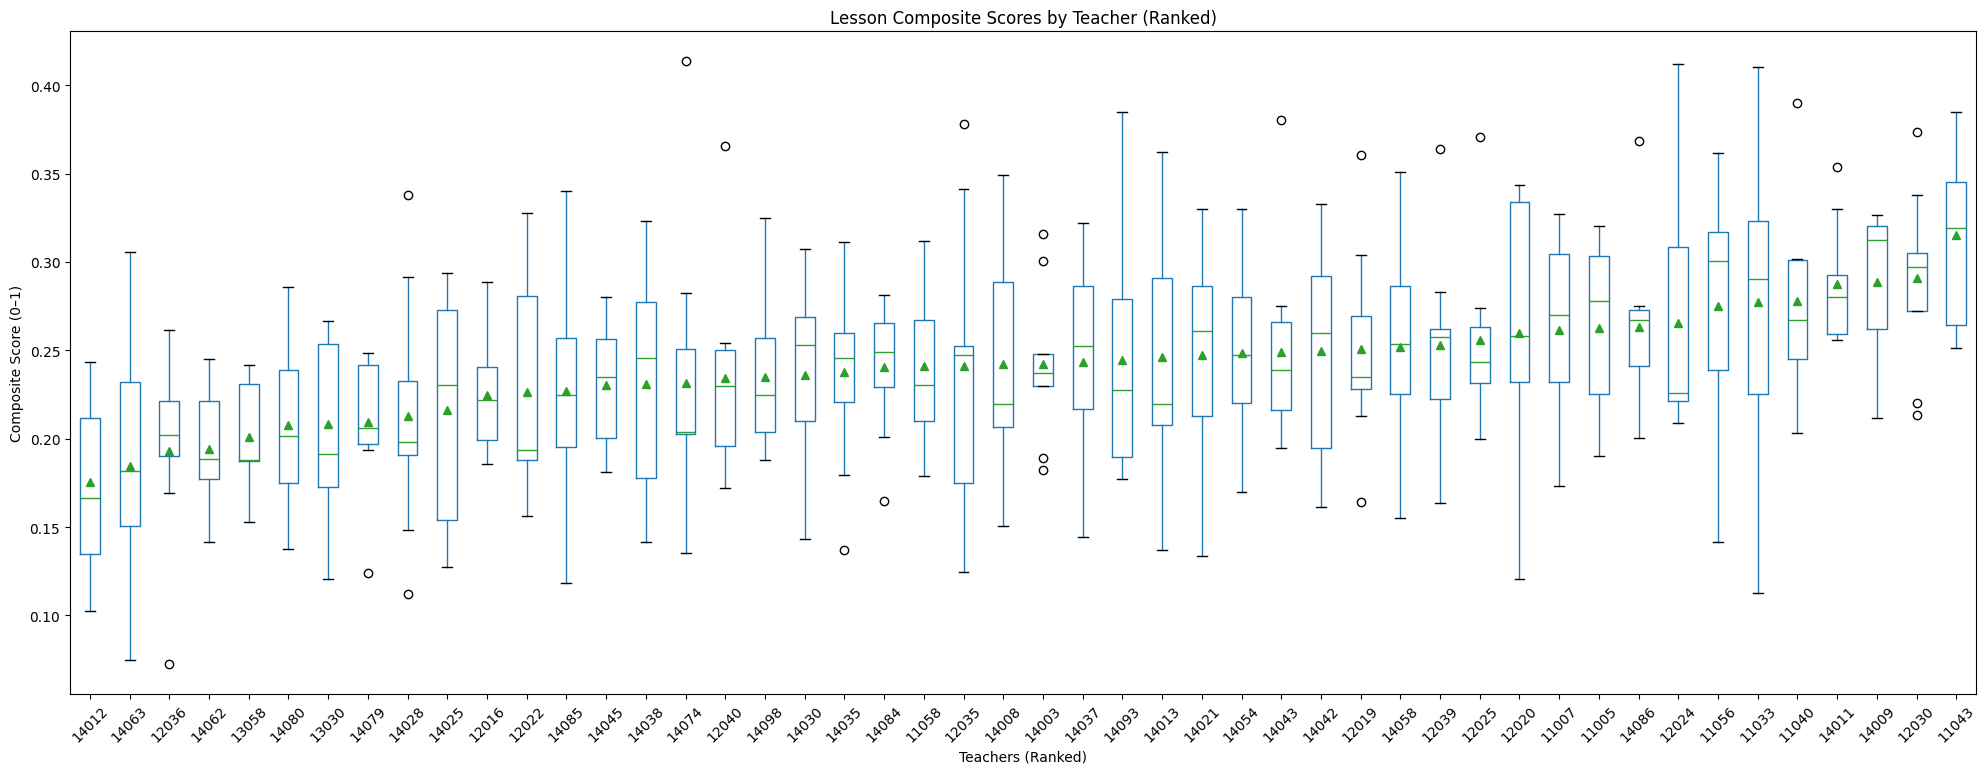

In [18]:
# Order teachers by mean score (best to worst)
teacher_order = (
    course_scores
    .groupby("NCTETID")["course_composite_score"]
    .mean()
    .sort_values(ascending=True)
    .index
)

ordered_df = course_scores.copy()
ordered_df["NCTETID"] = pd.Categorical(
    ordered_df["NCTETID"],
    categories=teacher_order,
    ordered=True
)

ordered_df = ordered_df.sort_values("NCTETID")

fig, ax = plt.subplots(figsize=(20, 8))

ordered_df.boxplot(
    column="course_composite_score",
    by="NCTETID",
    showmeans=True,
    vert=True,
    grid=False,
    ax=ax
)

plt.title("Lesson Composite Scores by Teacher (Ranked)")
plt.suptitle("")
plt.xlabel("Teachers (Ranked)")
ax.tick_params(axis='x', labelrotation=45)
plt.ylabel("Composite Score (0–1)")

plt.tight_layout()
plt.show()

In [19]:
teacher_summary = (
    course_scores
    .groupby("NCTETID")
    .agg(
        mean_score=("course_composite_score", "mean"),
        std_score=("course_composite_score", "std"),
        n_courses=("OBSID", "nunique")
    )
    .sort_values("mean_score", ascending=False)
)

teacher_summary

,mean_score,std_score,n_courses
NCTETID,,,
11043,0.315409,0.050812,9
12030,0.290842,0.050943,9
14009,0.288623,0.040597,9
14011,0.287760,0.033441,9
11040,0.277969,0.053366,9
11033,0.277597,0.096723,9
11056,0.274910,0.065982,9
12024,0.265491,0.067318,9
14086,0.263394,0.046095,9


In [20]:
df = teacher_summary.copy()

# 1) Quantile bins
df["quantile"] = pd.qcut(df["mean_score"], q=10, labels=False, duplicates="drop")

# Keep the min and max quantile values (in case qcut dropped some bins)
qmin = df["quantile"].min()
qmax = df["quantile"].max()

# 2) Target the middle of each quantile: compute distance to median
df["q_median"] = df.groupby("quantile")["mean_score"].transform("median")
df["dist_to_middle"] = (df["mean_score"] - df["q_median"]).abs()

# 3) Selection
# 3a) First quantile: min(mean_score)
first_q = (
    df[df["quantile"] == qmin]
    .reset_index()
    .sort_values(["mean_score", "std_score"], ascending=[True, True])
    .head(1)
)

# 3b) Last quantile: max(mean_score)
last_q = (
    df[df["quantile"] == qmax]
    .reset_index()
    .sort_values(["mean_score", "std_score"], ascending=[False, True])
    .head(1)
)

# 3c) Middle of each quantile
middle_q = (
    df[df["quantile"].between(qmin + 1, qmax - 1)]
    .reset_index()
    .sort_values(
        ["quantile", "dist_to_middle", "std_score", "mean_score"],
        ascending=[True, True, True, False]
    )
    .groupby("quantile", as_index=False)
    .head(1)
)

selected = (
    pd.concat([first_q, middle_q, last_q], ignore_index=True)
    .sort_values("mean_score", ascending=False)
)

selected_teachers = selected["NCTETID"].tolist()

selected

,NCTETID,mean_score,std_score,n_courses,quantile,q_median,dist_to_middle
9,11043,0.315409,0.050812,9,9,0.288623,0.026785
8,12024,0.265491,0.067318,9,8,0.265491,0.000000
7,12025,0.255681,0.048272,9,7,0.255681,0.000000
6,14043,0.249148,0.055807,9,6,0.249325,0.000178
5,14093,0.244532,0.069101,9,5,0.244532,0.000000
4,11058,0.241225,0.044955,9,4,0.241225,0.000000
3,14098,0.235164,0.040837,11,3,0.234652,0.000512
2,14085,0.227025,0.073629,9,2,0.227025,0.000000
1,14079,0.209292,0.038462,9,1,0.209292,0.000000
0,14012,0.175450,0.048053,9,0,0.193134,0.017684


Text(0, 0.5, 'Teacher')

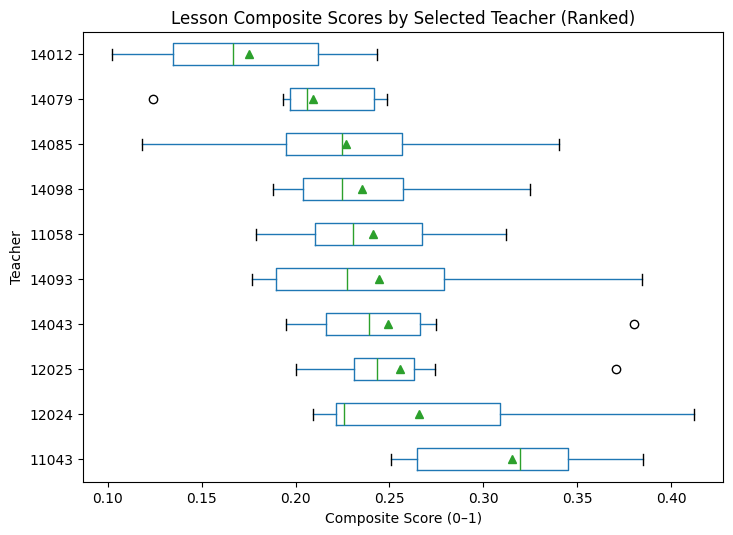

In [21]:
plot_df = ordered_df[
    ordered_df["NCTETID"].isin(selected_teachers)
].copy()

plot_df["NCTETID"] = pd.Categorical(
    plot_df["NCTETID"],
    categories=selected_teachers,
    ordered=True
)

plot_df = plot_df.sort_values("NCTETID")

fig, ax = plt.subplots(figsize=(8, 6))

plot_df.boxplot(
    column="course_composite_score",
    by="NCTETID",
    vert=False,
    grid=False,
    showmeans=True,
    ax=ax
)

plt.title("Lesson Composite Scores by Selected Teacher (Ranked)")
plt.suptitle("")
plt.xlabel("Composite Score (0–1)")
plt.ylabel("Teacher")

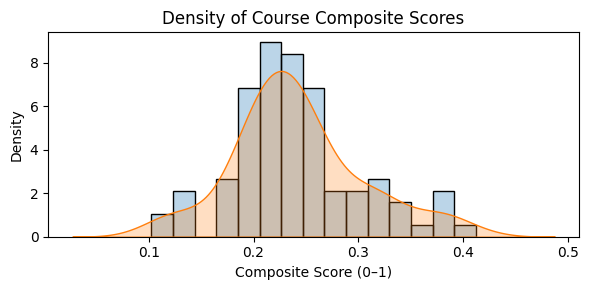

In [ ]:
plot_df = course_scores[
    course_scores["NCTETID"].isin(selected_teachers)
].copy()

plot_df = plot_df.sort_values("course_composite_score")

fig, ax = plt.subplots(figsize=(6, 3))

sns.histplot(
    data=plot_df,
    x="course_composite_score",
    stat="density",
    bins=15,
    alpha=0.3
)

sns.kdeplot(
    data=plot_df,
    x="course_composite_score",
    fill=True,
    ax=ax
)

ax.set_xlabel("Composite Score (0–1)")
ax.set_ylabel("Density")
ax.set_title("Density of Lesson Composite Scores")

plt.tight_layout()

In [ ]:
selected_courses = plot_df["OBSID"].to_list()
print("Number of selected lessons:", len(selected_courses))
print("Selected lessons OBSIDs:", selected_courses)

Number of selected courses: 92
Selected course OBSIDs: ['1017', '992', '4601', '762', '327', '4411', '4128', '2996', '1016', '4627', '4413', '4538', '761', '500', '2146', '4652', '4206', '361', '4057', '4012', '4694', '727', '2447', '2356', '2681', '703', '882', '569', '2085', '925', '4693', '2727', '4755', '2445', '4746', '2981', '921', '4198', '44', '1015', '2694', '890', '2120', '324', '253', '4107', '705', '4730', '2084', '4259', '4417', '2522', '2983', '4502', '4352', '2028', '2007', '2114', '4160', '4248', '940', '2593', '2597', '4157', '2076', '730', '763', '4677', '990', '2919', '2797', '4159', '910', '4239', '2636', '1084', '2520', '4364', '2123', '4010', '19', '2370', '2737', '2765', '2094', '22', '2117', '577', '4654', '244', '4089', '120']


# Create the subsets

In [ ]:
# for file in selected_files:
#     df = pd.read_csv(
#         file,
#         dtype={"NCTETID":"string", "OBSID": "string", 'DISTRICT': "string", "SCHOOLYEAR_SP": "string"},
#         encoding="utf-8",
#         low_memory=False,
#     )
#     teacher_subset = df[df["OBSID"].isin(selected_courses)]
    
#     total_lenght += len(teacher_subset)
#     filename = os.path.basename(file)
#     teacher_subset.to_csv(filename, index=False, encoding="utf-8")
#     print(filename[4:-12], "- length:", len(teacher_subset))

APLPROB - length: 429
CWCM - length: 654
DIFFINST - length: 61
DIRINST - length: 429
ETCA - length: 654
EXPL - length: 654
LANGIMP - length: 654
LCP - length: 654
LESSEFFIC - length: 31
LINK - length: 654
LLC - length: 30
MAJERR - length: 654
MATCON - length: 225
MGEN - length: 654
MLANG - length: 654
MMETH - length: 654
MMSM - length: 225
MQI3 - length: 61
MQI5 - length: 92
MQI_CHECK - length: 61
OERR4 - length: 435
OERR - length: 429
ORICH4 - length: 435
ORICH - length: 429
ORIENT - length: 61
OSPMMR4 - length: 435
OWWS4 - length: 435
OWWS - length: 429
REMED - length: 654
SMALDIS - length: 225
SMQR - length: 654
STEXPL - length: 654
STUCON - length: 225
SUMM - length: 61
TASKDEVMAT - length: 31
TSTUDEA - length: 31
USEPROD - length: 429
WCDISS - length: 654
